# Doctor Study Analysis

Analysis of the human labeling study conducted via the labeling UI.
Two study arms:
- **Realism study** (`realism.json`): participants judged conversations as 'real' or 'simulated' and rated realism subscores.
- **Personality study** (`personality.json`): participants reconstructed HEXACO personality axes (1–3) for extreme-personality PatientsWithPersonality and their paired PatientSim configurations.

In [1]:
%load_ext autoreload
%autoreload 2

import os

os.chdir("..")

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import logging

from patient_simulator.misc.plotting import (
    hexaco_distance_to_truth,
    plot_category_fraction,
    plot_confidence_stacked_bar,
    plot_countplot,
    plot_flag_reasons,
    plot_hexaco_rater_alignment,
    plot_kappa_heatmap,
    plot_majority_agreement,
    plot_personality_extreme_difference,
    plot_rater_comparison_scores,
    save_to_figures,
    sort_patient_types,
    PATIENT_TYPE_PALETTE,
)

logging.getLogger().setLevel(logging.WARNING)

## Data Loading

In [4]:
LABELS_DIR = Path("results/labels")

# testuser contains uniform placeholder data (all scores identical) — excluded
EXCLUDE_USERS = {"testuser"}


def load_realism_data(labels_dir, exclude_users):
    rows = []
    for user_dir in labels_dir.iterdir():
        if user_dir.name in exclude_users:
            continue
        realism_path = user_dir / "realism.json"
        if not realism_path.exists():
            continue
        data = json.loads(realism_path.read_text())
        for task_id, label in data["labels"].items():
            assignment = data["task_assignments"].get(task_id, {})
            rows.append(
                {
                    "task_id": task_id,
                    "user": user_dir.name,
                    "conv_id": assignment.get("conv_id"),
                    "source": assignment.get("source"),
                    "is_real": assignment.get("is_real"),
                    **label,
                }
            )
    return pd.DataFrame(rows)


def load_personality_data(labels_dir, exclude_users):
    rows = []
    for user_dir in labels_dir.iterdir():
        if user_dir.name in exclude_users:
            continue
        personality_path = user_dir / "personality.json"
        if not personality_path.exists():
            continue
        data = json.loads(personality_path.read_text())
        for task_id, label in data["labels"].items():
            assignment = data["task_assignments"].get(task_id, {})
            rows.append(
                {
                    "task_id": task_id,
                    "user": user_dir.name,
                    "conv_id": assignment.get("conv_id"),
                    "simulator": assignment.get("simulator"),
                    "personality_reconstructed_H": label.get("h"),
                    "personality_reconstructed_E": label.get("e"),
                    "personality_reconstructed_X": label.get("x"),
                    "personality_reconstructed_A": label.get("a"),
                    "personality_reconstructed_C": label.get("c"),
                    "personality_reconstructed_O": label.get("o"),
                }
            )
    return pd.DataFrame(rows)


PATIENT_TYPE_RENAME = {
    "PatientSimPatient": "PatientSim",
    "AgentClinicPatient": "AgentClinic",
    "BaselinePatient": "Human Rephrase",
}


def patient_type_from_source(source):
    if source == "real":
        return "Human Actor"
    base = source.split("_")[0]
    # EverydayPatient was renamed to PatientsWithPersonality for the paper
    if base.startswith("PatientsWithPersonality") or base == "EverydayPatient":
        return "PatientsWithPersonality"
    return PATIENT_TYPE_RENAME.get(base, base)


realism_df = load_realism_data(LABELS_DIR, EXCLUDE_USERS)
realism_df["patient_type"] = realism_df["source"].apply(patient_type_from_source)

personality_df = load_personality_data(LABELS_DIR, EXCLUDE_USERS)

print(
    f"Realism labels:     {len(realism_df)} rows from {realism_df['user'].nunique()} user(s)"
)
print(
    f"Personality labels: {len(personality_df)} rows from {personality_df['user'].nunique()} user(s)"
)

# in both realism and personality data replace the user with a user_id that is "#{number}"


def anonymize_users(df):
    user_mapping = {user: f"#{i + 1}" for i, user in enumerate(df["user"].unique())}
    df["user"] = df["user"].map(user_mapping)
    return df


realism_df = anonymize_users(realism_df)
personality_df = anonymize_users(personality_df)

Realism labels:     210 rows from 7 user(s)
Personality labels: 210 rows from 7 user(s)


In [ ]:
realism_df

,task_id,user,conv_id,source,is_real,classification,confidence,symptom_realism,information_control,style_realism,flagged_turns,timestamp,comment,patient_type
0,VS000#0,#1,VS000,PatientSimPatient_persplain_cefrB_dazednormal_...,False,simulated,2,3,4,3,[],2026-04-15T10:11:03.742933,NaN,PatientSim
1,VS000#1,#1,VS000,EverydayPatient_H2_E1_X1_A2_C2_O1_LB,False,real,3,3,4,5,[],2026-04-15T10:11:10.174296,NaN,PatientsWithPersonality
2,VS000#2,#1,VS000,real,True,real,2,3,3,4,[],2026-04-15T10:11:14.747573,NaN,Human Actor
3,VS001#0,#1,VS001,AgentClinicPatient_nobias,False,simulated,3,3,1,3,[],2026-04-15T10:11:16.672389,NaN,AgentClinic
4,VS001#1,#1,VS001,PatientSimPatient_persplain_cefrB_dazednormal_...,False,simulated,1,4,3,4,"[{'turn_idx': 6, 'reasons': ['too_informative']}]",2026-04-15T10:11:19.278850,NaN,PatientSim
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,VS014#1,#7,VS014,PatientSimPatient_persplain_cefrB_dazednormal_...,False,real,3,4,4,4,[],2026-04-19T18:37:27.946222,,PatientSim
206,VS014#2,#7,VS014,real,True,simulated,2,2,2,4,"[{'turn_idx': 2, 'reasons': ['inconsistent_wit...",2026-04-19T18:38:52.500868,,Human Actor
207,VS015#0,#7,VS015,AgentClinicPatient_nobias,False,simulated,2,2,2,2,"[{'turn_idx': 12, 'reasons': ['medically_impla...",2026-04-19T18:40:25.662086,,AgentClinic
208,VS015#1,#7,VS015,PatientSimPatient_persplain_cefrB_dazednormal_...,False,simulated,2,2,3,4,"[{'turn_idx': 11, 'reasons': ['medically_impla...",2026-04-19T18:41:45.962827,,PatientSim


## Realism Study

Participants judged each conversation as *real* or *simulated* and rated realism sub-dimensions on a 1–5 scale.

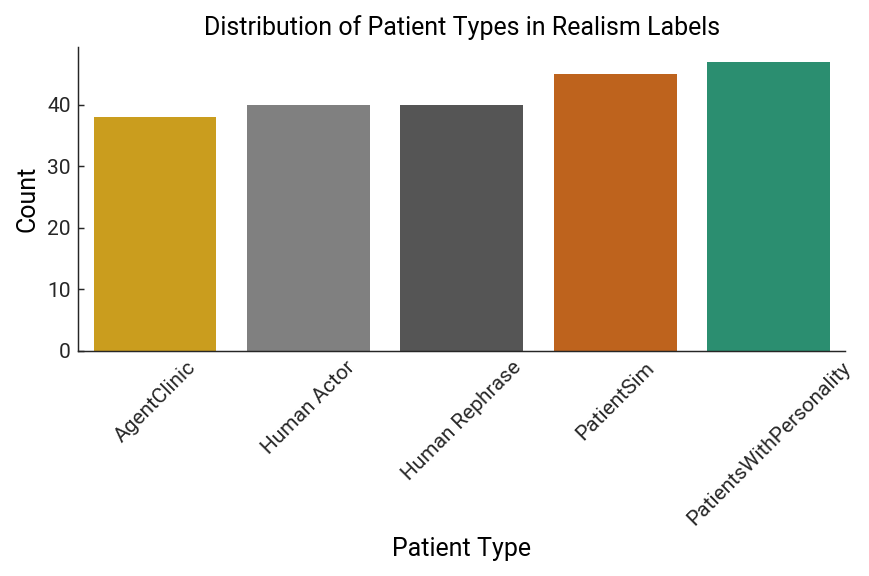

In [5]:
# just a gut check dont store
plot_countplot(
    realism_df,
    x="patient_type",
    title="Distribution of Patient Types in Realism Labels",
    x_label="Patient Type",
)

Merged rows: 170, judge data matched: 170


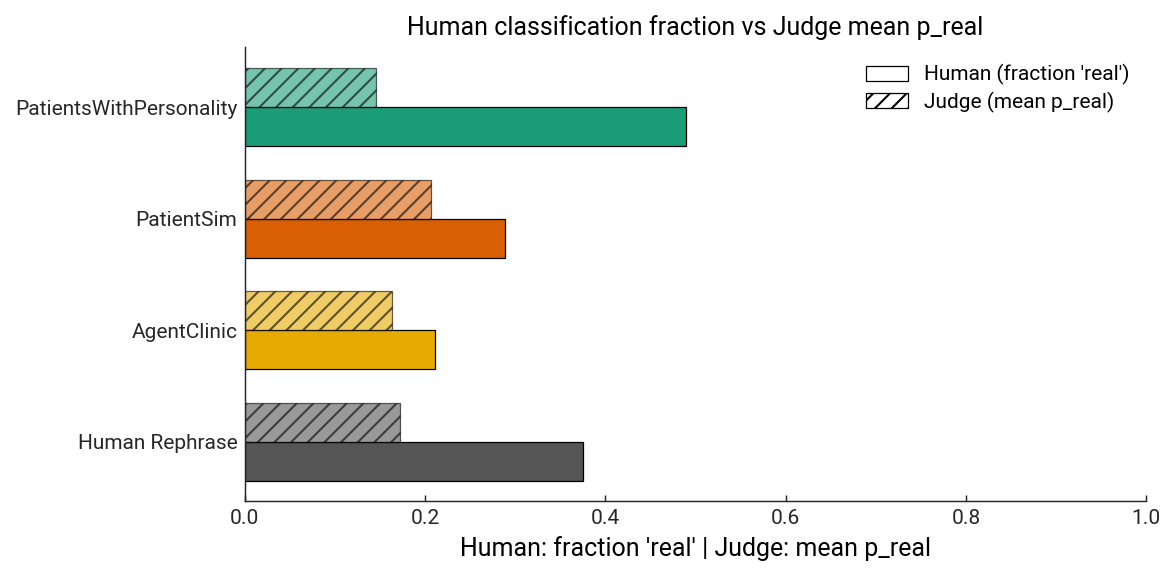

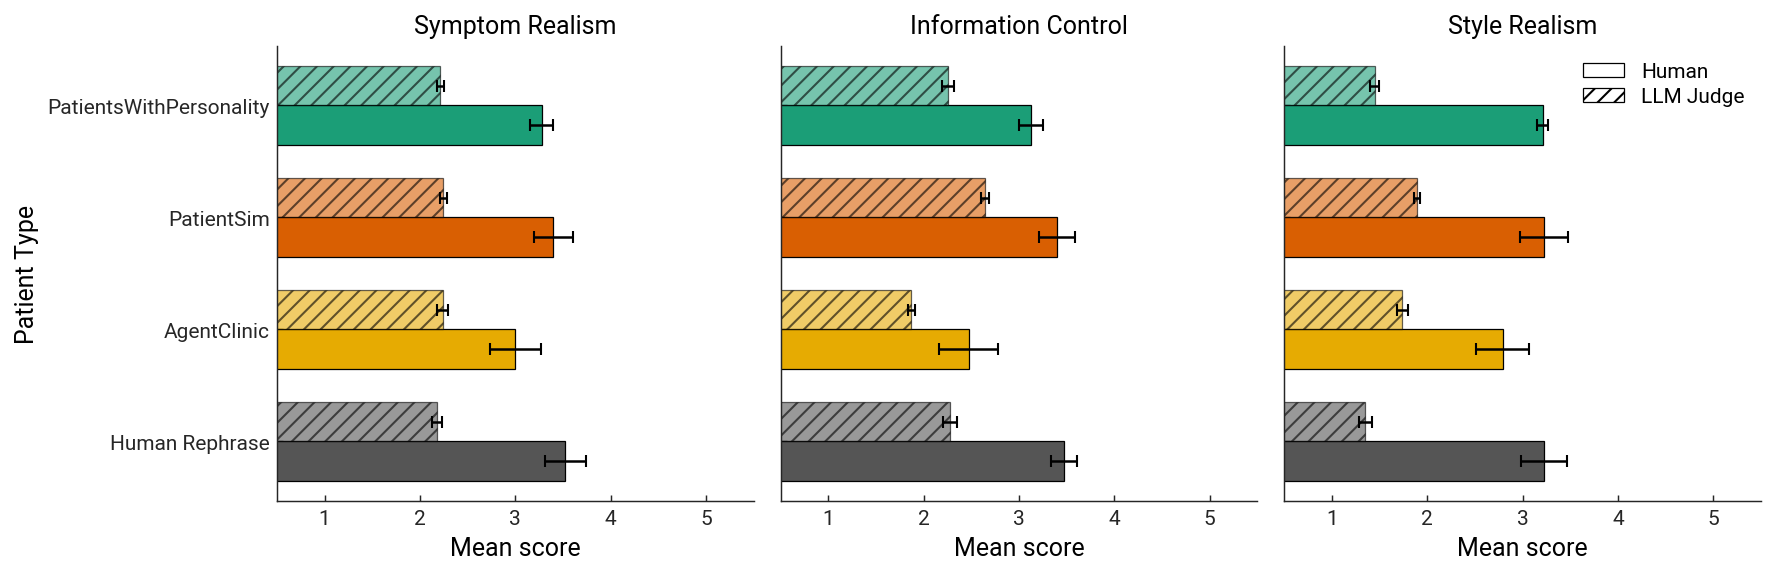

In [6]:
JUDGE_COLS = [
    "judge_p_real",
    "judge_classification",
    "judge_symptom_realism",
    "judge_information_control",
    "judge_style_realism",
]


# source in realism.json uses EverydayPatient prefix; CSV uses PatientsWithPersonality
def source_to_patient_name(source):
    return source.replace("EverydayPatient", "PatientsWithPersonality")


sim_realism_df = realism_df[realism_df["source"] != "real"].copy()
sim_realism_df["patient_name"] = sim_realism_df["source"].map(source_to_patient_name)

judge_df = pd.read_csv("results/patient_comparison_default/all_conversations.csv")
judge_df = judge_df[
    judge_df["conversation_name"].isin(sim_realism_df["conv_id"].unique())
]

merged_df = sim_realism_df.merge(
    judge_df[["conversation_name", "patient_name"] + JUDGE_COLS],
    left_on=["conv_id", "patient_name"],
    right_on=["conversation_name", "patient_name"],
    how="left",
)

print(
    f"Merged rows: {len(merged_df)}, judge data matched: {merged_df['judge_classification'].notna().sum()}"
)

categories = list(
    reversed(sort_patient_types(merged_df["patient_type"].dropna().unique().tolist()))
)
human_frac = (
    merged_df.groupby("patient_type")["classification"]
    .apply(lambda s: (s == "real").mean())
    .reindex(categories)
)
judge_p = merged_df.groupby("patient_type")["judge_p_real"].mean().reindex(categories)

y = np.arange(len(categories))
width = 0.35
bar_colors = [PATIENT_TYPE_PALETTE.get(c, "gray") for c in categories]

fig, ax = plt.subplots(figsize=(8, 4))
for i, (cat, color) in enumerate(zip(categories, bar_colors)):
    ax.barh(
        y[i] - width / 2,
        human_frac[cat],
        width,
        color=color,
        edgecolor="black",
        linewidth=0.6,
    )
    ax.barh(
        y[i] + width / 2,
        judge_p[cat],
        width,
        color=color,
        hatch="///",
        edgecolor="black",
        linewidth=0.6,
        alpha=0.6,
    )

ax.set_yticks(y)
ax.set_yticklabels(categories)
ax.set_xlabel("Human: fraction 'real' | Judge: mean p_real")
ax.set_xlim(0, 1)
ax.set_title("Human classification fraction vs Judge mean p_real")
ax.legend(
    handles=[
        mpatches.Patch(
            facecolor="white",
            edgecolor="black",
            linewidth=0.6,
            label="Human (fraction 'real')",
        ),
        mpatches.Patch(
            facecolor="white",
            edgecolor="black",
            linewidth=0.6,
            hatch="///",
            label="Judge (mean p_real)",
        ),
    ],
    frameon=False,
)
fig.tight_layout()
# save_to_figures(fig, "doctor_study_rater_comparison_p_real")
plt.show()

plot_rater_comparison_scores(
    merged_df,
    category="patient_type",
    human_metrics=["symptom_realism", "information_control", "style_realism"],
    judge_metrics=[
        "judge_symptom_realism",
        "judge_information_control",
        "judge_style_realism",
    ],
    metric_labels=["Symptom Realism", "Information Control", "Style Realism"],
    user_col="user",
    # save_as="doctor_study_rater_comparison_scores",
)

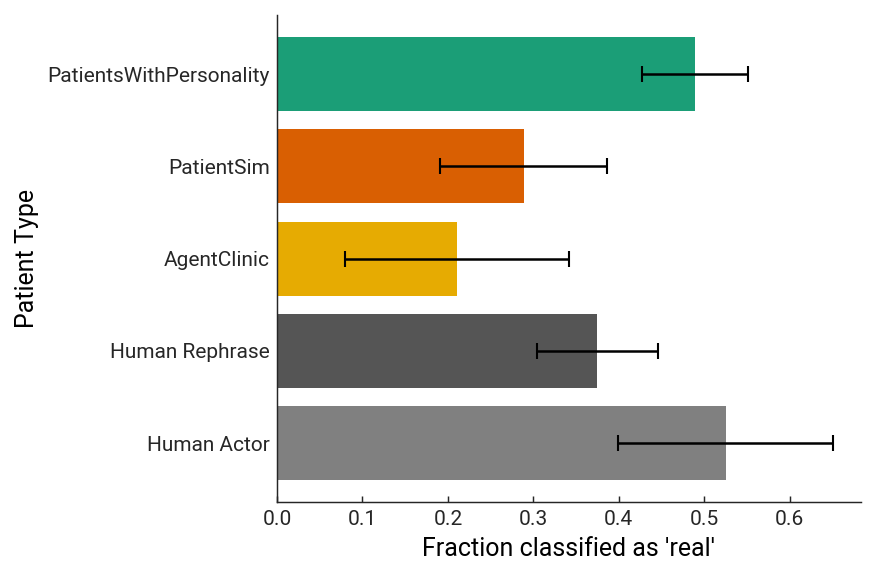

,patient_type,fraction,error
1,Human Actor,0.525000,0.125946
2,Human Rephrase,0.375000,0.071022
0,AgentClinic,0.210526,0.131498
3,PatientSim,0.288889,0.097782
4,PatientsWithPersonality,0.489362,0.061853


In [7]:
plot_category_fraction(
    realism_df,  # [realism_df["user"] == "#4"],
    category="patient_type",
    value_col="classification",
    user_col="user",
    target_value="real",
    x_label="Fraction classified as 'real'",
    save_as="doctor_study_realism_classification_fraction",
    error_type="sem",
)

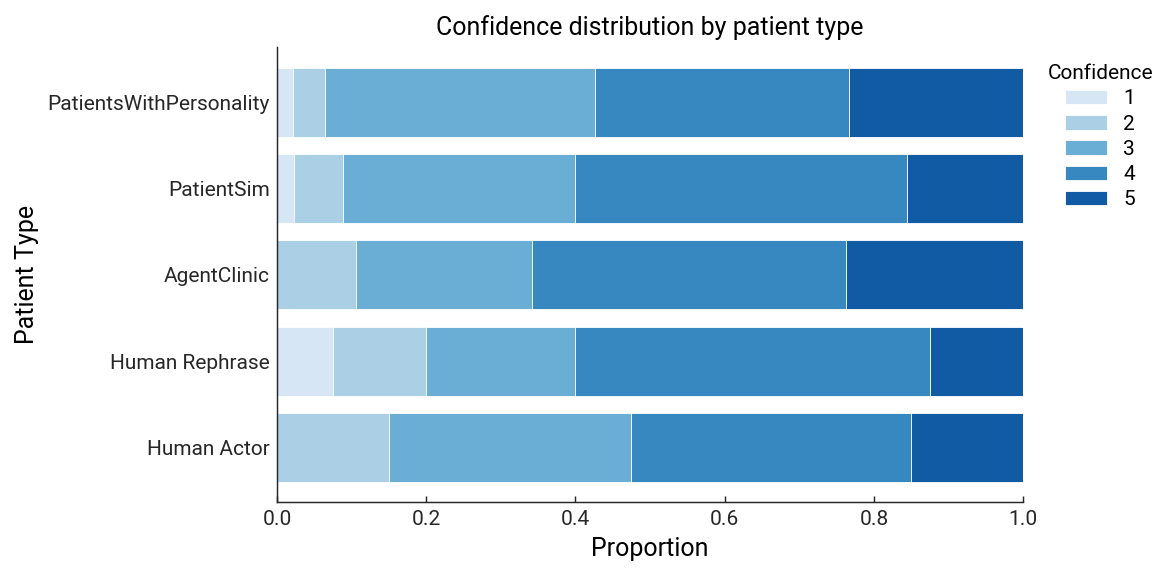

confidence,1,2,3,4,5
patient_type,,,,,
Human Actor,0.000000,0.150000,0.325000,0.375000,0.150000
Human Rephrase,0.075000,0.125000,0.200000,0.475000,0.125000
AgentClinic,0.000000,0.105263,0.236842,0.421053,0.236842
PatientSim,0.022222,0.066667,0.311111,0.444444,0.155556
PatientsWithPersonality,0.021277,0.042553,0.361702,0.340426,0.234043


In [8]:
plot_confidence_stacked_bar(
    realism_df,
    category="patient_type",
    confidence_col="confidence",
    title="Confidence distribution by patient type",
    # save_as="doctor_study_realism_confidence",
)

In [22]:
from itertools import combinations

realism_df["item_key"] = realism_df["conv_id"] + "||" + realism_df["source"]
user_items = realism_df.groupby("user")["item_key"].agg(set)

overlap_rows = []
for u1, u2 in combinations(sorted(user_items.index), 2):
    s1, s2 = user_items[u1], user_items[u2]
    inter = len(s1 & s2)
    union = len(s1 | s2)
    overlap_rows.append(
        {
            "user_a": u1,
            "user_b": u2,
            "shared_simulators": inter,
            "jaccard": inter / union if union else np.nan,
        }
    )

overlap_df = pd.DataFrame(overlap_rows)
print(f"Items per user: {user_items.apply(len).to_dict()}")
print(f"Total unique (conv, source) items: {len(set().union(*user_items))}")
print(
    f"Average shared simulators per annotator pair: {overlap_df['shared_simulators'].mean():.2f}"
)
print(
    f"Average Jaccard overlap per annotator pair:   {overlap_df['jaccard'].mean():.3f}"
)
overlap_df

Items per user: {'#1': 30, '#2': 30, '#3': 30, '#4': 30, '#5': 30, '#6': 30, '#7': 30}
Total unique (conv, source) items: 57
Average shared simulators per annotator pair: 17.19
Average Jaccard overlap per annotator pair:   0.410


,user_a,user_b,shared_simulators,jaccard
0,#1,#2,21,0.538462
1,#1,#3,19,0.463415
2,#1,#4,22,0.578947
3,#1,#5,19,0.463415
4,#1,#6,11,0.224490
5,#1,#7,21,0.538462
6,#2,#3,18,0.428571
7,#2,#4,16,0.363636
8,#2,#5,17,0.395349
9,#2,#6,15,0.333333


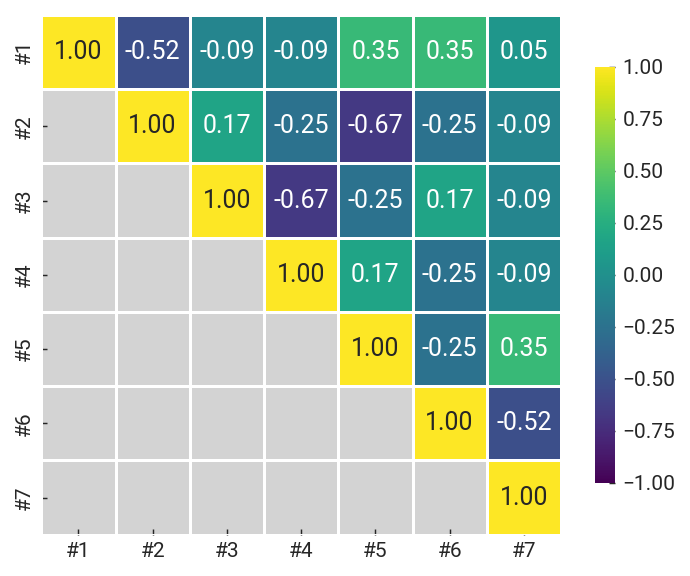

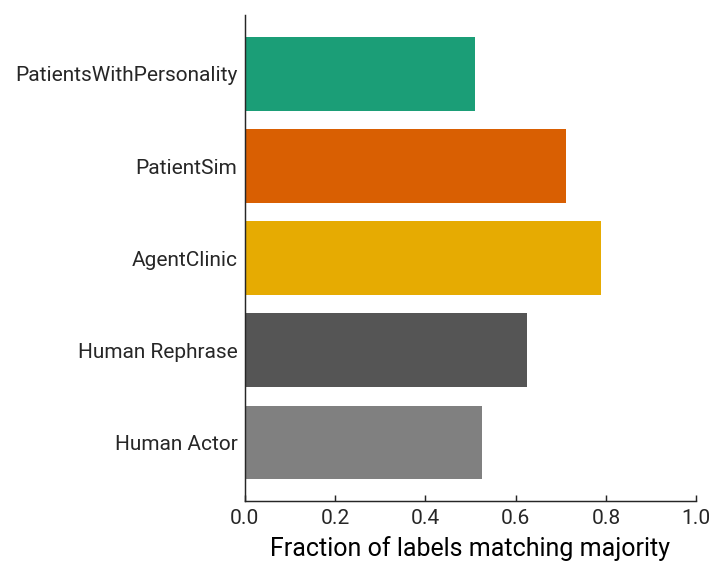

patient_type
Human Actor                0.525000
Human Rephrase             0.625000
AgentClinic                0.789474
PatientSim                 0.711111
PatientsWithPersonality    0.510638
Name: classification, dtype: float64

In [10]:
plot_kappa_heatmap(
    realism_df,
    user_col="user",
    value_col="classification",
    conv_id_col="conv_id",
    save_as="doctor_study_interdoctor_agreement_kappa",
)

plot_majority_agreement(
    realism_df,
    user_col="user",
    value_col="classification",
    category="patient_type",
    save_as="doctor_study_interdoctor_agreement_majority",
)

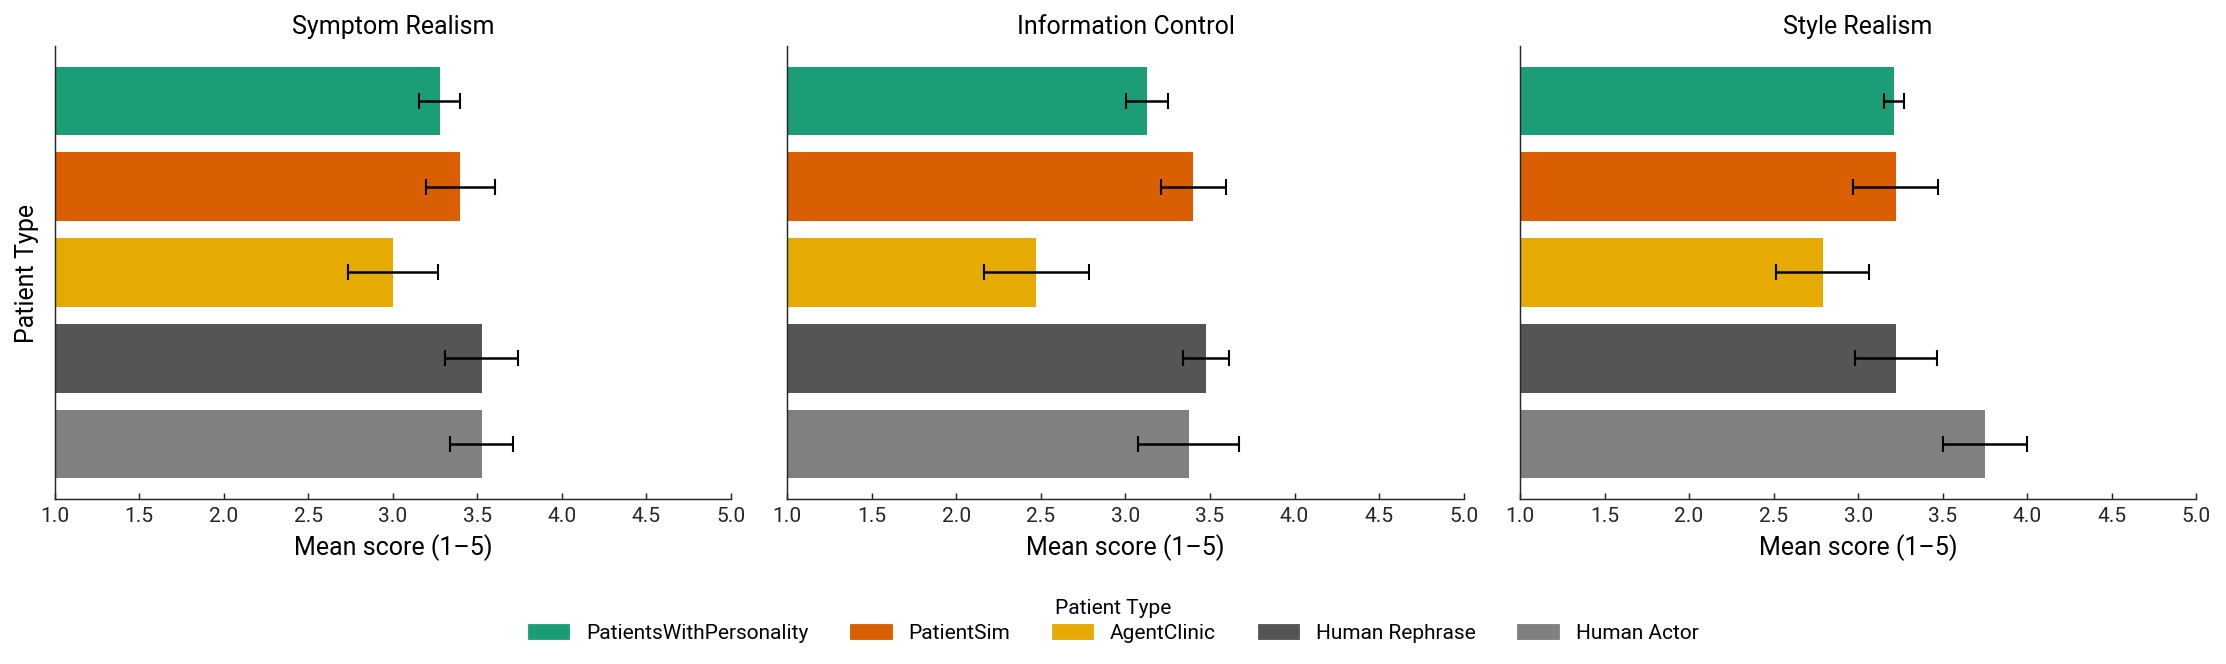

In [11]:
REALISM_SUBSCORES = ["symptom_realism", "information_control", "style_realism"]
SUBSCORE_LABELS = ["Symptom Realism", "Information Control", "Style Realism"]

patient_types = sort_patient_types(
    realism_df["patient_type"].dropna().unique().tolist()
)
patient_types_plot = list(reversed(patient_types))
colors = [PATIENT_TYPE_PALETTE.get(pt, "gray") for pt in patient_types]
colors_plot = list(reversed(colors))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, metric, label in zip(axes, REALISM_SUBSCORES, SUBSCORE_LABELS):
    means = (
        realism_df.groupby("patient_type")[metric].mean().reindex(patient_types_plot)
    )
    sems = (
        realism_df.groupby(["patient_type", "user"])[metric]
        .mean()
        .groupby("patient_type")
        .sem()
        .reindex(patient_types_plot)
    )
    ax.barh(patient_types_plot, means, xerr=sems, capsize=4, color=colors_plot)
    ax.set_title(label)
    ax.set_xlabel("Mean score (1–5)")
    ax.set_xlim(1, 5)
    if ax is not axes[0]:
        ax.set_yticklabels([])

axes[0].set_ylabel("Patient Type")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
fig.legend(
    handles,
    patient_types,
    title="Patient Type",
    loc="lower center",
    ncol=len(patient_types),
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    fontsize=10,
)

fig.tight_layout()
save_to_figures(fig, "doctor_study_realism_subscores")
plt.show()

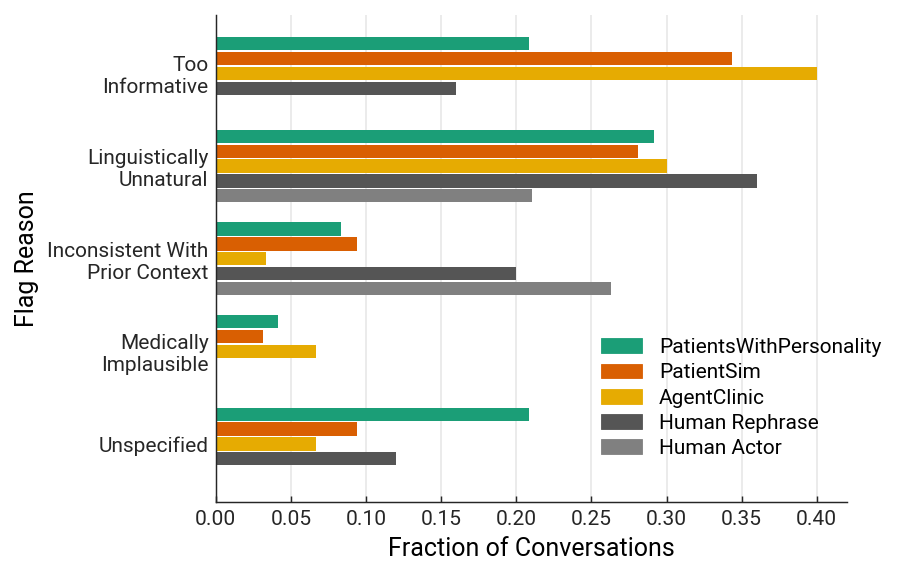

In [12]:
plot_flag_reasons(
    realism_df[realism_df["classification"] == "simulated"],
    category="patient_type",
    save_as="doctor_study_flag_reasons",
    min_count=4,
    reason_order=[
        "Too Informative",
        "Linguistically Unnatural",
        "Inconsistent With Prior Context",
        "Medically Implausible",
        "Unspecified",
    ],
)

In [13]:
flag_source_df = realism_df[realism_df["classification"] == "simulated"]

flag_rows = []
for _, row in flag_source_df.iterrows():
    reasons_in_conv = set()
    for flag in row.get("flagged_turns") or []:
        for reason in flag.get("reasons") or ["unspecified"]:
            normalized = reason.lower().strip() if reason else "unspecified"
            reasons_in_conv.add(
                "unspecified" if normalized in ("unspecified", "other") else normalized
            )
    for reason in reasons_in_conv:
        flag_rows.append({"patient_type": row["patient_type"], "reason": reason})

flag_long_df = pd.DataFrame(flag_rows)
total_per_cat = flag_source_df.groupby("patient_type").size()

flag_reason_table = (
    flag_long_df.groupby(["reason", "patient_type"])
    .size()
    .unstack("patient_type", fill_value=0)
    .div(total_per_cat, axis=1)
    .reindex(columns=sort_patient_types(total_per_cat.index.tolist()))
    .fillna(0)
    .sort_values(
        by=sort_patient_types(total_per_cat.index.tolist())[0], ascending=False
    )
)
flag_reason_table.index = [r.replace("_", " ").title() for r in flag_reason_table.index]
flag_reason_table.columns.name = None

flag_reason_table.round(3)

,PatientsWithPersonality,PatientSim,AgentClinic,Human Rephrase,Human Actor
Linguistically Unnatural,0.292,0.281,0.300,0.36,0.211
Unspecified,0.208,0.094,0.067,0.12,0.000
Too Informative,0.208,0.344,0.400,0.16,0.000
Inconsistent With Prior Context,0.083,0.094,0.033,0.20,0.263
Medically Implausible,0.042,0.031,0.067,0.00,0.000
Uninformative,0.042,0.000,0.000,0.00,0.000
Non Response,0.000,0.000,0.000,0.00,0.158


## Personality Reconstruction Study

Participants rated HEXACO personality axes (1–3 scale) for conversations from extreme-personality PatientsWithPersonality
and their closest paired PatientSim configuration, following the pairing table below.
Autorater values are from `results/patient_comparison_default/all_conversations.csv`, filtered to the same 5 conversations.

| HEXACO axis at extreme | PatientsWithPersonality | Paired PatientSim |
|---|---|---|
| Honesty-Humility (H) | H3, E1, X1, A1, C1, O1 | distrust / recall=low / dazed=normal |
| Emotionality (E) | H1, E3, X1, A1, C1, O1 | overanxious / recall=high / dazed=normal |
| Extraversion (X) | H1, E1, X3, A1, C1, O1 | verbose / recall=high / dazed=normal |
| Agreeableness (A) | H1, E1, X1, A3, C1, O1 | impatient / recall=high / dazed=normal |
| Conscientiousness (C) | H1, E1, X1, A1, C3, O1 | plain / recall=low / dazed=high |
| Openness (O) | H1, E1, X1, A1, C1, O3 | distrust / recall=high / dazed=normal |

In [14]:
personality_df

,task_id,user,conv_id,simulator,personality_reconstructed_H,personality_reconstructed_E,personality_reconstructed_X,personality_reconstructed_A,personality_reconstructed_C,personality_reconstructed_O
0,VS015#0,#1,VS015,PatientSimPatient_persplain_cefrB_dazedhigh_re...,2,2,2,2,2,1
1,VS015#1,#1,VS015,PatientSimPatient_persdistrust_cefrB_dazednorm...,3,3,2,3,2,3
2,VS015#2,#1,VS015,PatientSimPatient_persimpatient_cefrB_dazednor...,2,3,1,3,2,3
3,VS015#3,#1,VS015,PatientSimPatient_persdistrust_cefrB_dazednorm...,3,2,2,3,2,2
4,VS015#4,#1,VS015,EverydayPatient_H1_E3_X1_A1_C1_O1_LB,1,2,3,2,3,1
...,...,...,...,...,...,...,...,...,...,...
205,VS024#1,#7,VS024,EverydayPatient_H1_E1_X1_A3_C1_O1_LB,1,3,2,2,1,2
206,VS024#2,#7,VS024,PatientSimPatient_persverbose_cefrB_dazednorma...,1,3,3,1,3,1
207,VS024#3,#7,VS024,PatientSimPatient_persplain_cefrB_dazedhigh_re...,2,3,1,1,3,1
208,VS024#4,#7,VS024,EverydayPatient_H1_E3_X1_A1_C1_O1_LB,1,3,3,2,3,2


In [15]:
# EverydayPatient was renamed to PatientsWithPersonality; the personality.json still uses the old name
PAIRINGS = [
    {
        "axis": "H",
        "everyday": "EverydayPatient_H3_E1_X1_A1_C1_O1_LB",
        "persona_csv": "PatientsWithPersonality_H3_E1_X1_A1_C1_O1_LB",
        "patientsim": "PatientSimPatient_persdistrust_cefrB_dazednormal_recalllow",
    },
    {
        "axis": "E",
        "everyday": "EverydayPatient_H1_E3_X1_A1_C1_O1_LB",
        "persona_csv": "PatientsWithPersonality_H1_E3_X1_A1_C1_O1_LB",
        "patientsim": "PatientSimPatient_persoveranxious_cefrB_dazednormal_recallhigh",
    },
    {
        "axis": "X",
        "everyday": "EverydayPatient_H1_E1_X3_A1_C1_O1_LB",
        "persona_csv": "PatientsWithPersonality_H1_E1_X3_A1_C1_O1_LB",
        "patientsim": "PatientSimPatient_persverbose_cefrB_dazednormal_recallhigh",
    },
    {
        "axis": "A",
        "everyday": "EverydayPatient_H1_E1_X1_A3_C1_O1_LB",
        "persona_csv": "PatientsWithPersonality_H1_E1_X1_A3_C1_O1_LB",
        "patientsim": "PatientSimPatient_persimpatient_cefrB_dazednormal_recallhigh",
    },
    {
        "axis": "C",
        "everyday": "EverydayPatient_H1_E1_X1_A1_C3_O1_LB",
        "persona_csv": "PatientsWithPersonality_H1_E1_X1_A1_C3_O1_LB",
        "patientsim": "PatientSimPatient_persplain_cefrB_dazedhigh_recalllow",
    },
    {
        "axis": "O",
        "everyday": "EverydayPatient_H1_E1_X1_A1_C1_O3_LB",
        "persona_csv": "PatientsWithPersonality_H1_E1_X1_A1_C1_O3_LB",
        "patientsim": "PatientSimPatient_persdistrust_cefrB_dazednormal_recallhigh",
    },
]

STUDY_CONVS = personality_df["conv_id"].unique().tolist()

# Human labels from personality.json
paired_rows = []
for pair in PAIRINGS:
    for patient_type, sim_name in [
        ("PatientsWithPersonality", pair["everyday"]),
        ("PatientSim", pair["patientsim"]),
    ]:
        subset = personality_df[personality_df["simulator"] == sim_name].copy()
        subset["hexaco_axis"] = pair["axis"]
        subset["patient_type"] = patient_type
        subset["rater"] = "Human"
        paired_rows.append(subset)
paired_df = pd.concat(paired_rows, ignore_index=True)

# Autorater labels from all_conversations.csv, filtered to the same conversations
autorater_df = pd.read_csv("results/patient_comparison_default/all_conversations.csv")
autorater_df = autorater_df[autorater_df["conversation_name"].isin(STUDY_CONVS)]

auto_rows = []
for pair in PAIRINGS:
    for patient_type, csv_name in [
        ("PatientsWithPersonality", pair["persona_csv"]),
        ("PatientSim", pair["patientsim"]),
    ]:
        subset = autorater_df[autorater_df["patient_name"] == csv_name].copy()
        subset = subset[
            [
                "personality_reconstructed_H",
                "personality_reconstructed_E",
                "personality_reconstructed_X",
                "personality_reconstructed_A",
                "personality_reconstructed_C",
                "personality_reconstructed_O",
            ]
        ].copy()
        subset["hexaco_axis"] = pair["axis"]
        subset["patient_type"] = patient_type
        subset["rater"] = "Autorater"
        auto_rows.append(subset)
auto_df = pd.concat(auto_rows, ignore_index=True)

print(f"Human labels:     {len(paired_df)} rows")
print(f"Autorater labels: {len(auto_df)} rows")
paired_df.groupby(["hexaco_axis", "patient_type", "rater"]).size().unstack(level=[1, 2])

Human labels:     198 rows
Autorater labels: 60 rows


patient_type,PatientSim,PatientsWithPersonality
rater,Human,Human
hexaco_axis,,
A,22,12
C,19,13
E,13,14
H,22,14
O,23,12
X,19,15


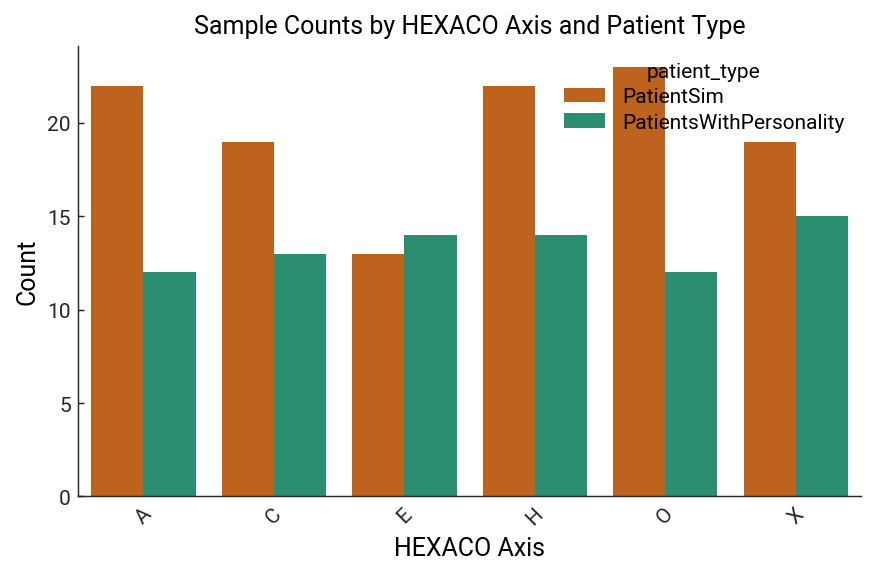

In [16]:
# dont save
plot_countplot(
    paired_df,
    x="hexaco_axis",
    hue="patient_type",
    title="Sample Counts by HEXACO Axis and Patient Type",
    x_label="HEXACO Axis",
)

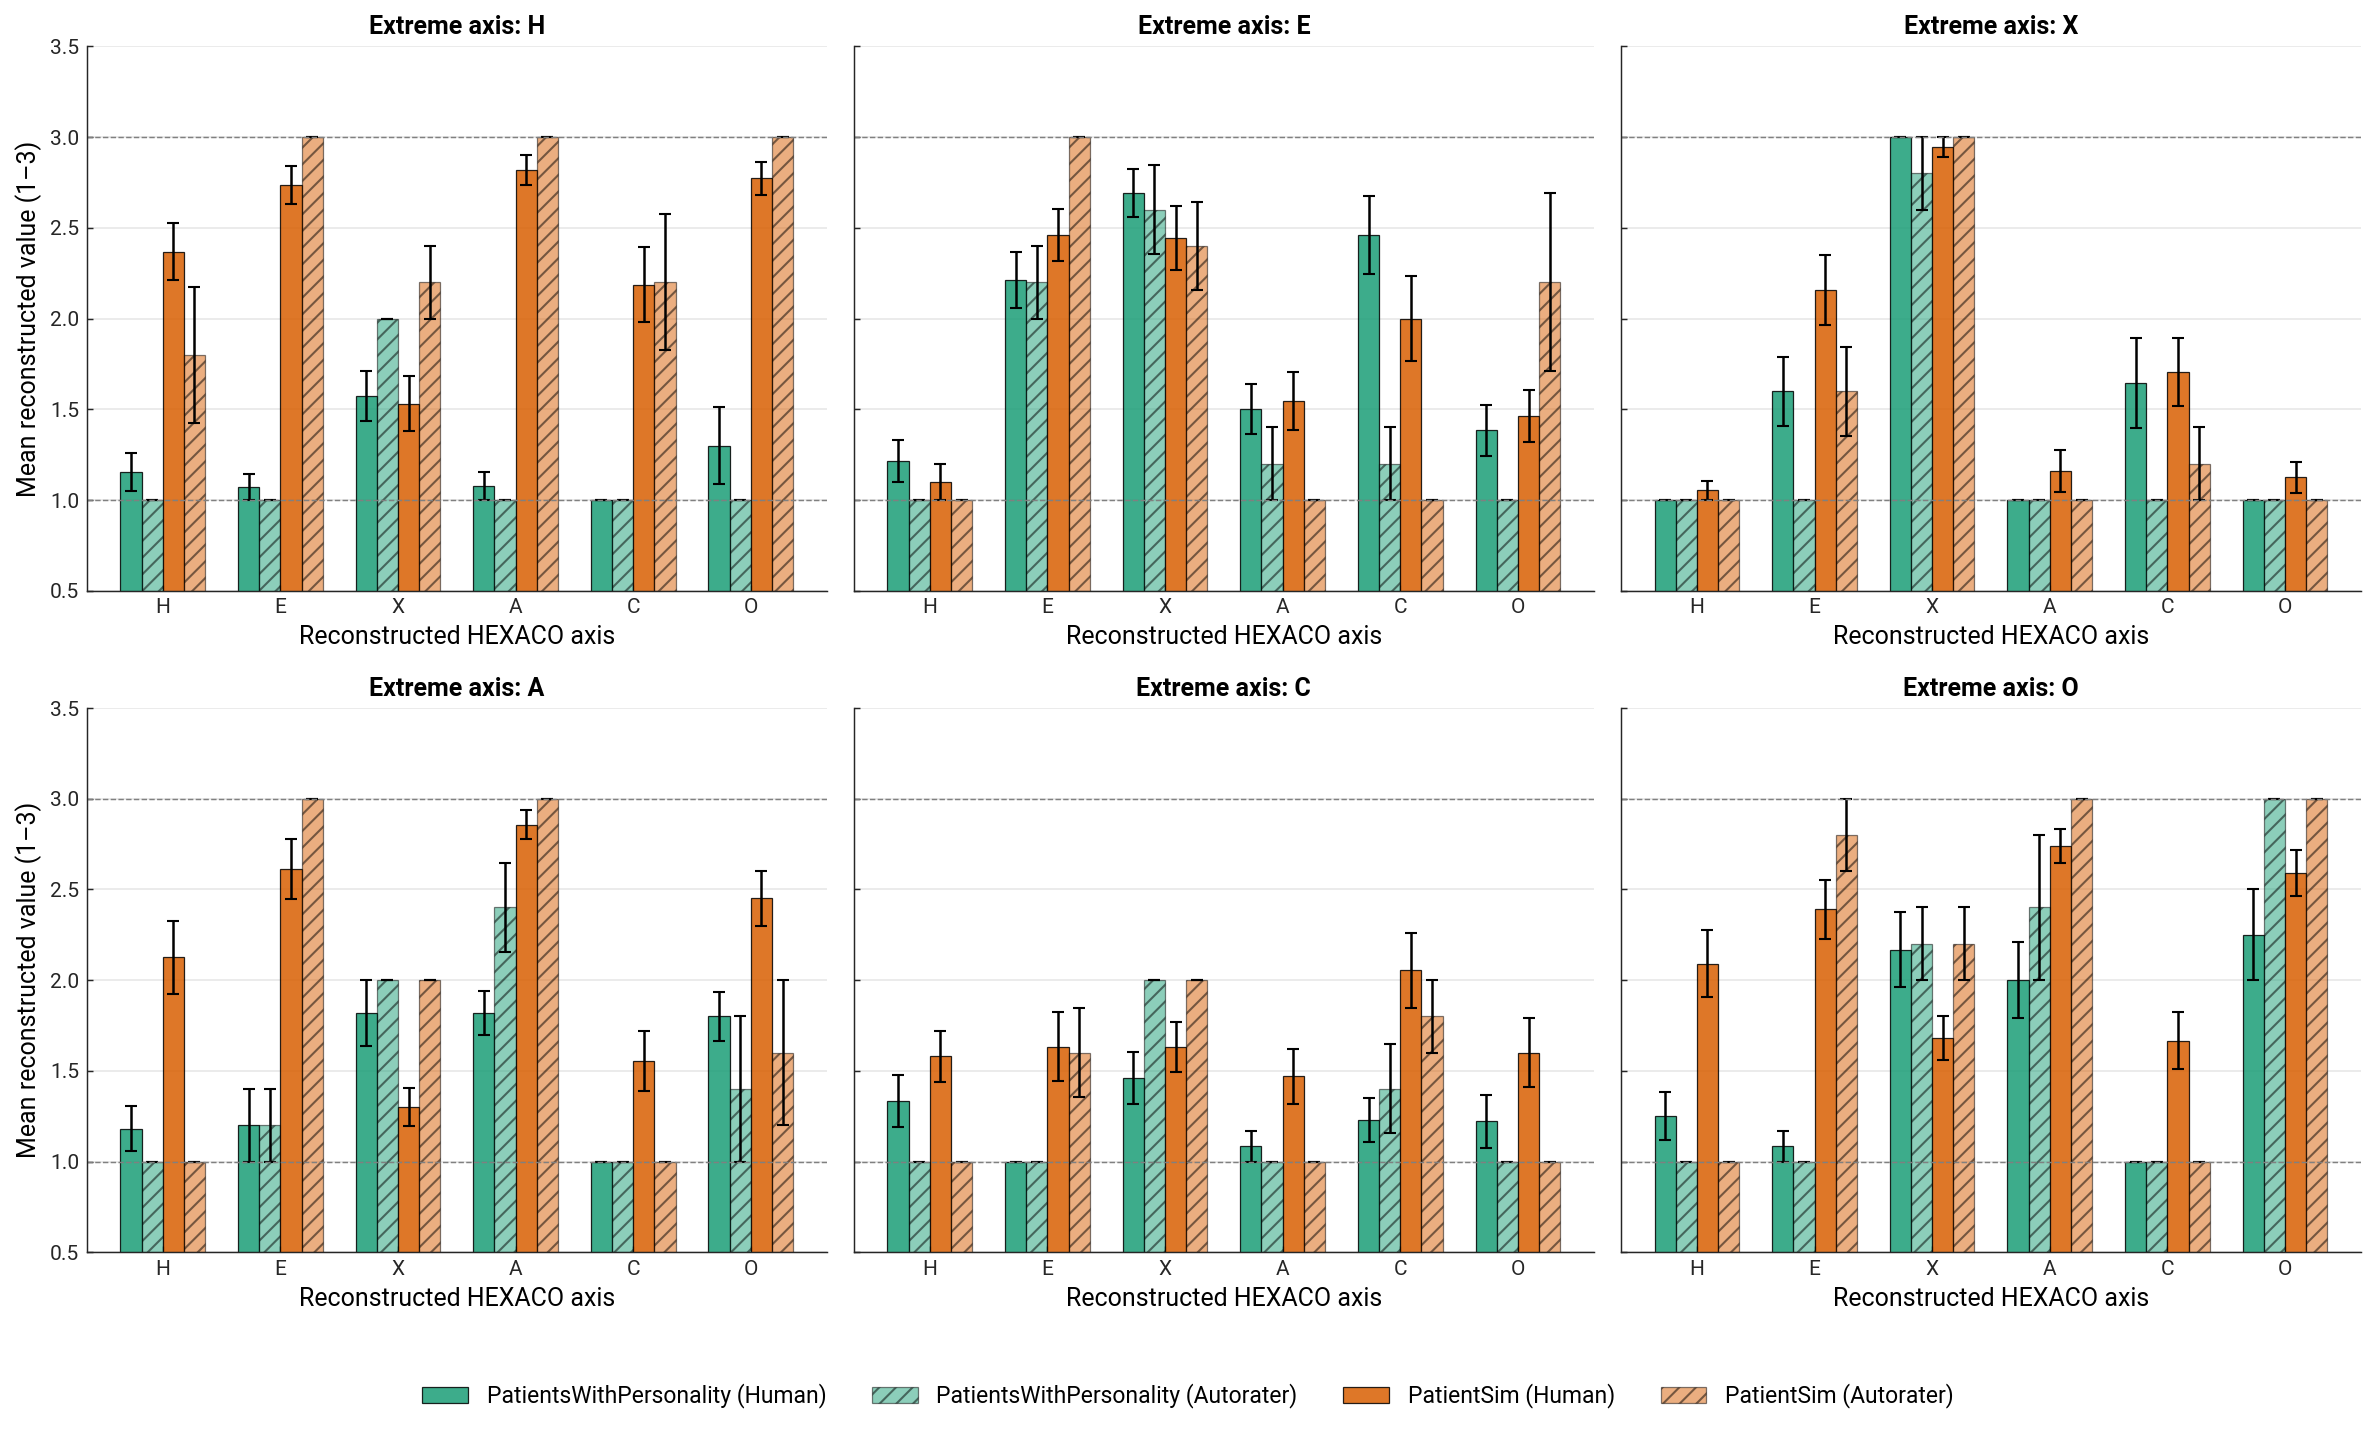

In [17]:
HEXACO_AXES = ["H", "E", "X", "A", "C", "O"]
REC_COLS = {ax: f"personality_reconstructed_{ax}" for ax in HEXACO_AXES}

GROUPS = [
    (
        "PatientsWithPersonality",
        "Human",
        PATIENT_TYPE_PALETTE["PatientsWithPersonality"],
        "",
    ),
    (
        "PatientsWithPersonality",
        "Autorater",
        PATIENT_TYPE_PALETTE["PatientsWithPersonality"],
        "///",
    ),
    ("PatientSim", "Human", PATIENT_TYPE_PALETTE["PatientSim"], ""),
    (
        "PatientSim",
        "Autorater",
        PATIENT_TYPE_PALETTE["PatientSim"],
        "///",
    ),
]

all_df = pd.concat([paired_df, auto_df], ignore_index=True)

# replace all 0s in the rec columns with NaN (should not turn down the average, just ignore those samples)
for col in REC_COLS.values():
    all_df[col] = all_df[col].replace(0, np.nan)

x = np.arange(len(HEXACO_AXES))
n_groups = len(GROUPS)
width = 0.18
offsets = np.linspace(-(n_groups - 1) / 2, (n_groups - 1) / 2, n_groups) * width

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for ax, pair in zip(axes, PAIRINGS):
    axis_label = pair["axis"]
    sub = all_df[all_df["hexaco_axis"] == axis_label]

    for i, (pt, rater, color, hatch) in enumerate(GROUPS):
        seg = sub[(sub["patient_type"] == pt) & (sub["rater"] == rater)]
        means = [seg[REC_COLS[a]].mean() for a in HEXACO_AXES]
        sems = [seg[REC_COLS[a]].sem() for a in HEXACO_AXES]
        ax.bar(
            x + offsets[i],
            means,
            width,
            yerr=sems,
            capsize=3,
            label=f"{pt} ({rater})" if ax is axes[0] else None,
            color=color,
            alpha=0.85 if rater == "Human" else 0.5,
            hatch=hatch,
            edgecolor="black",
            linewidth=0.6,
        )

    ax.set_title(f"Extreme axis: {axis_label}", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(HEXACO_AXES)
    ax.set_xlabel("Reconstructed HEXACO axis")
    ax.set_ylim(0.5, 3.5)
    ax.axhline(1, color="gray", linewidth=0.7, linestyle="--")
    ax.axhline(3, color="gray", linewidth=0.7, linestyle="--")
    ax.grid(axis="y", alpha=0.3)

for i in range(2):
    axes[i * 3].set_ylabel("Mean reconstructed value (1–3)")

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels_,
    loc="upper center",
    ncol=n_groups,
    bbox_to_anchor=(0.5, -0.02),
    frameon=False,
    fontsize=11,
)
# fig.suptitle(
#     "Average Reconstructed HEXACO Distribution per Persona\n"
#     "(solid = human doctors, hatched = autorater, by extreme axis)",
#     y=1.06,
#     fontsize=13,
#     fontweight="bold",
# )
fig.tight_layout()
# save_to_figures(fig, "doctor_study_hexaco_reconstruction")
plt.show()

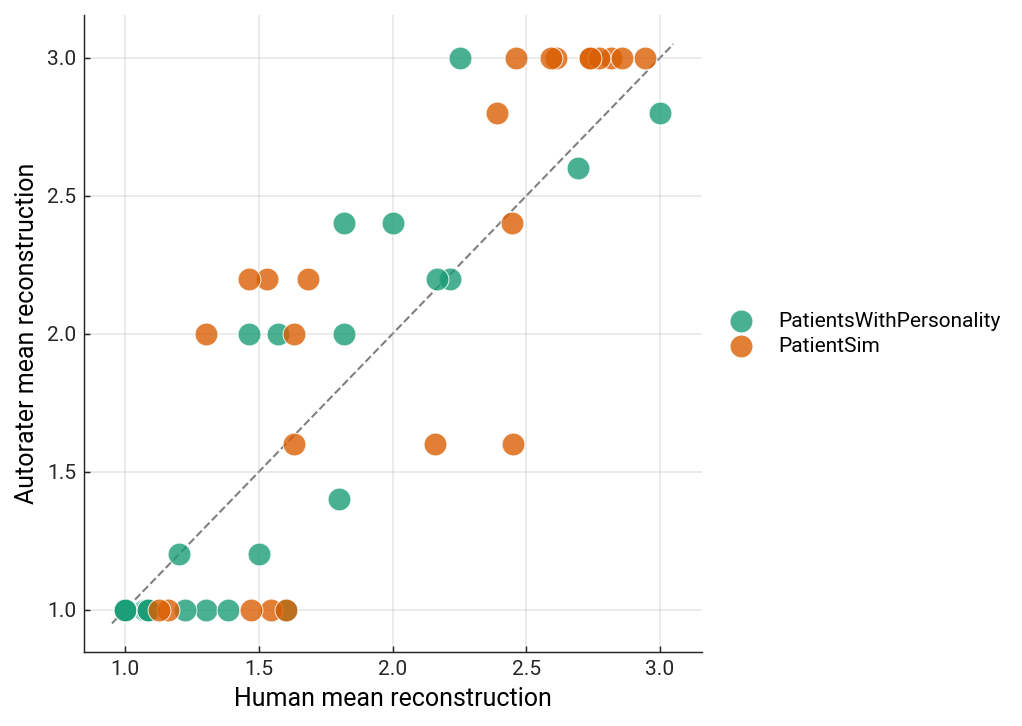

(np.float64(0.8736145064276265), np.float64(0.8513861049630913))

In [18]:
plot_hexaco_rater_alignment(
    all_df,
    exclude_axes=["H", "C"],
    save_as="doctor_study_hexaco_rater_alignment",
)

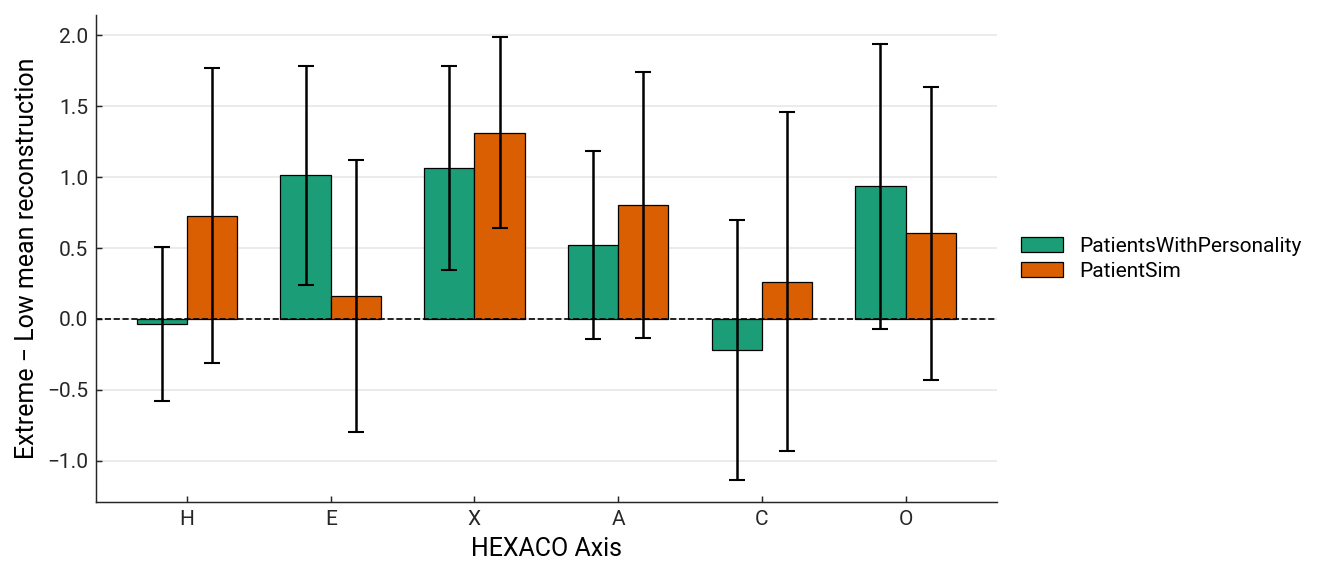

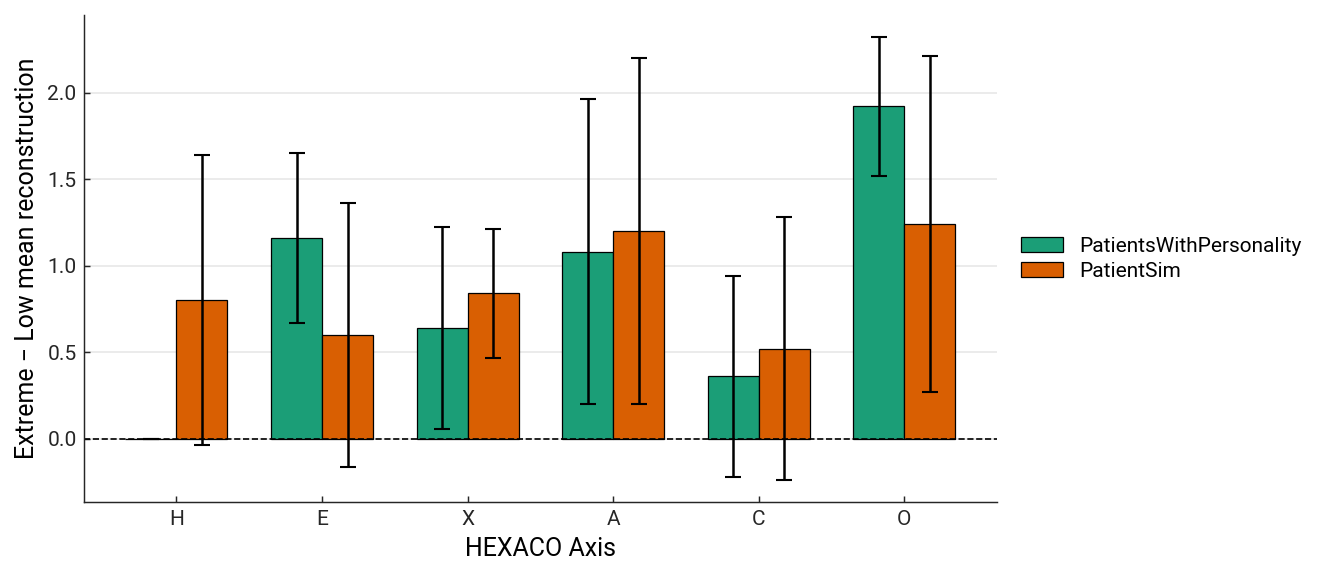

In [19]:
plot_personality_extreme_difference(
    all_df,
    rater="Human",
    title="Personality Axis Discrimination: Extreme vs. Low (Human)",
    show_sd=True,
)

plot_personality_extreme_difference(
    all_df,
    rater="Autorater",
    title="Personality Axis Discrimination: Extreme vs. Low (Autorater)",
    show_sd=True,
)

In [20]:
distance_table = hexaco_distance_to_truth(all_df)
distance_table.round(3)

axis                                   H      E      X      A      C      O  \
rater     patient_type                                                        
Autorater PatientSim               0.200  1.167  0.967  0.667  0.433  0.633   
          PatientsWithPersonality  0.333  0.167  1.000  0.367  0.300  0.067   
Human     PatientSim               0.638  1.208  0.533  0.885  0.820  0.870   
          PatientsWithPersonality  0.468  0.308  0.756  0.427  0.680  0.391   

axis                                mean  
rater     patient_type                    
Autorater PatientSim               0.678  
          PatientsWithPersonality  0.372  
Human     PatientSim               0.826  
          PatientsWithPersonality  0.505